In [1]:
import os
import sys
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Link to the root directory to import our src modules
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_insurance_data

# Load the dataset
df = load_insurance_data()

✅ Successfully loaded dataset from: ..\data\insurance_data.csv


In [2]:
# Separate the groups
male_claims = df[df['Gender'] == 'Male']['TotalClaims'].dropna()
female_claims = df[df['Gender'] == 'Female']['TotalClaims'].dropna()

# Run an Independent T-Test
t_stat, p_value = stats.ttest_ind(male_claims, female_claims, equal_var=False)

print(f"--- Gender Risk T-Test ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Result: Reject the Null Hypothesis (Significant difference exists between genders!).")
else:
    print("Result: Fail to reject the Null Hypothesis (No significant difference found).")

--- Gender Risk T-Test ---
T-Statistic: -0.0547
P-Value: 0.956371266680949
Result: Fail to reject the Null Hypothesis (No significant difference found).


In [3]:
# Create a list of claim arrays for each unique province
provinces = df['Province'].unique()
province_groups = [df[df['Province'] == p]['TotalClaims'].dropna() for p in provinces]

# Run One-Way ANOVA
f_stat, p_value_anova = stats.f_oneway(*province_groups)

print(f"--- Province Risk ANOVA Test ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value_anova}")

if p_value_anova < alpha:
    print("Result: Reject the Null Hypothesis (Geography significantly impacts claim risk!).")
else:
    print("Result: Fail to reject the Null Hypothesis.")

--- Province Risk ANOVA Test ---
F-Statistic: 1.6340
P-Value: 0.16262721551134246
Result: Fail to reject the Null Hypothesis.


In [ ]:
# Create the contingency table using the correct 'Claimed' column
contingency_table = pd.crosstab(df['VehicleType'], df['Claimed'])

# Run the Chi-Square test of independence
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"--- Vehicle Type Chi-Squared Test ---")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-Value: {p_value_chi2}")

# Interpret the results
if p_value_chi2 < 0.05:
    print("Result: Reject the Null Hypothesis (Vehicle Type is strongly associated with claiming behaviors!)")
else:
    print("Result: Fail to reject the Null Hypothesis (Vehicle Type and claiming behaviors are independent).")

KeyError: 'HasClaim'

C:\Users\hiwot\AppData\Local\Temp\ipykernel_9024\1546690365.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='TotalClaims', data=df, palette='Set2')


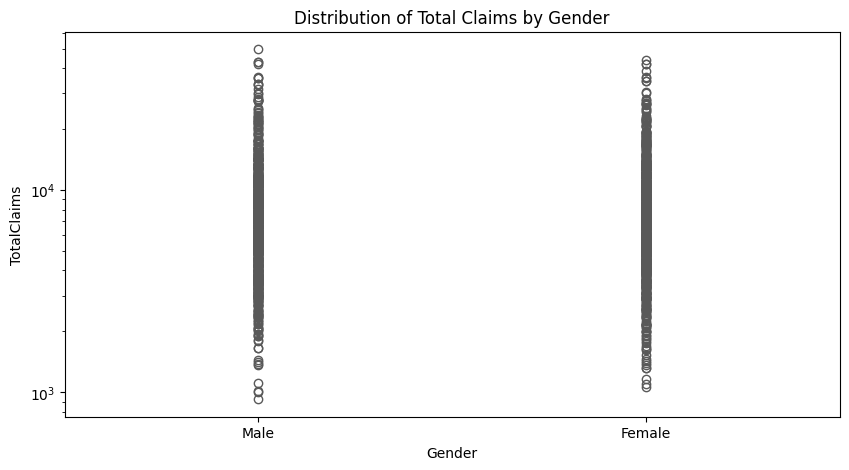

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Gender', y='TotalClaims', data=df, palette='Set2')
plt.title('Distribution of Total Claims by Gender')
plt.yscale('log') # Useful if claim amounts have huge outliers
plt.show()

In [6]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate']
